# BITCOIN PRICE PREDICTOR

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse


In [2]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf

In [8]:
data = yf.download("BTC-USD", "2024-01-01", "2026-06-25", auto_adjust=True)
data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-06-20,64239.675781,64307.136719,63149.660156,63535.808594,17486384117
2026-06-21,63237.539062,64506.578125,63221.000000,64242.324219,15739619591
2026-06-22,63952.105469,65544.000000,63233.531250,63240.789062,26561496819
2026-06-23,62668.019531,64196.562500,61893.207031,63952.792969,29608942370
2026-06-24,60995.132812,63097.757812,59029.855469,62663.031250,42644106535


In [5]:
data.shape

(906, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 906 entries, 2024-01-01 to 2026-06-24
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   906 non-null    float64
 1   (High, BTC-USD)    906 non-null    float64
 2   (Low, BTC-USD)     906 non-null    float64
 3   (Open, BTC-USD)    906 non-null    float64
 4   (Volume, BTC-USD)  906 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 42.5 KB


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,906.000000,906.000000,906.000000,906.000000,9.060000e+02
mean,81996.692277,83390.996400,80475.440152,81975.808594,4.397978e+10
std,20705.310147,20876.974744,20541.274132,20735.635736,2.304622e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65609.306641,66943.375000,63932.939453,65608.986328,2.763705e+10
50%,79451.628906,81554.632812,78052.519531,79450.996094,3.968728e+10
75%,98329.193359,100461.072266,96413.878906,98334.242188,5.482933e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


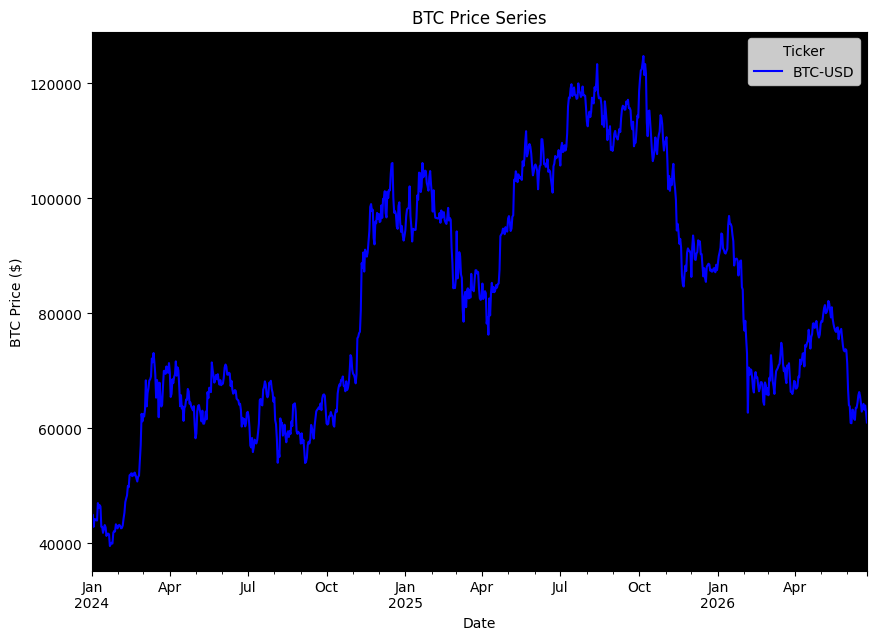

In [10]:
data.Close.plot(figsize=(10,7), color='b').set_facecolor('black')
plt.ylabel('BTC Price ($)')
plt.title('BTC Price Series')
plt.show()

<Axes: ylabel='Count'>

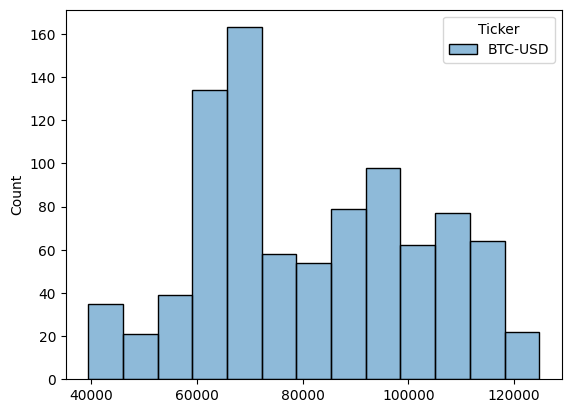

In [11]:
sns.histplot(data["Close"])

<Axes: ylabel='Count'>

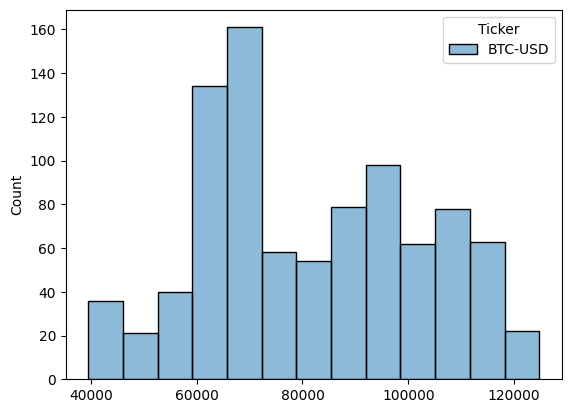

In [12]:
sns.histplot(data["Open"])

<Axes: ylabel='Count'>

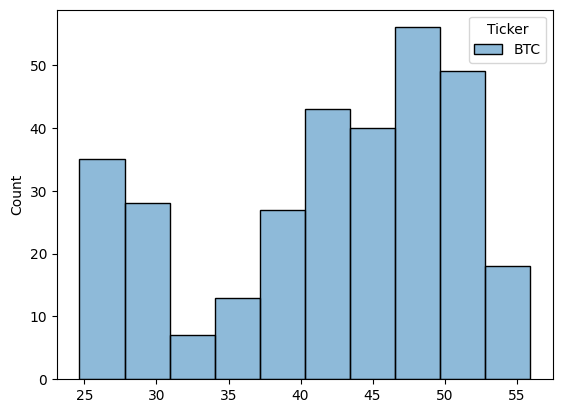

In [11]:
sns.histplot(data["High"])

In [17]:
X = data.drop('Close', axis=1)
y = data['Close']

In [134]:
X_train, y_train = X.iloc[0:int(0.8*960)], y.iloc[0:int(0.8*960)]
X_test, y_test = X.iloc[int(0.8*960):], y.iloc[int(0.8*960):]

In [135]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((768, 4), (138, 4), (768, 1), (138, 1))

# UTILS

In [48]:
model_names = []
model_rmse = []
model_r2_score = []

In [122]:
from datetime import datetime
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score
import joblib

def eval_save_model(model):
    model.fit(X_train, y_train)    
    name = model.__class__.__name__
    rmse_model = rmse(model.predict(X_test), y_test)
    r2_score_model = r2_score(model.predict(X_test), y_test)
    
    model_names.append(name)
    model_rmse.append(rmse_model)
    model_r2_score.append(r2_score_model)
    print(f'{name}:\n\tRMSE:{rmse_model}\n\tR2-score:{r2_score_model}')

def save_perfs(perfs, fname=None):
    if fname is None:
        fname = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    perfs.to_csv(f'models/perfs/{fname}.csv')

def save_model(model, fname):
    joblib.dump(model, f'models/saved{fname}.pkl',compress=3)

def reset():
    model_names.clear()
    model_rmse.clear()
    model_r2_score.clear()

# BASELINE MODELS (V1) WITHOUT PREPROCESSING

## Linear models

In [57]:
from sklearn.linear_model import LinearRegression

eval_save_model(LinearRegression())

LinearRegression:
	RMSE:575.8762008906998
	R2-score:0.9891401951330798


In [58]:
from sklearn.linear_model import Lasso

eval_save_model(Lasso())

Lasso:
	RMSE:582.3962390276511
	R2-score:0.9889147035191103


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.615e+08, tolerance: 3.643e+07
  model = cd_fast.enet_coordinate_descent(


In [59]:
from sklearn.linear_model import Ridge

eval_save_model(Ridge())

Ridge:
	RMSE:575.8762009346067
	R2-score:0.989140195129297


## SUPPORT VECTOR MACHINE

In [60]:
from sklearn.svm import SVR


eval_save_model(SVR())

SVR:
	RMSE:17092.672980663625
	R2-score:-130362.52925359421


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## KNN

In [61]:
from sklearn.neighbors import KNeighborsRegressor

eval_save_model(KNeighborsRegressor())

KNeighborsRegressor:
	RMSE:16226.720524757495
	R2-score:-0.6552873200203657


## TREE

In [63]:
from sklearn.tree import DecisionTreeRegressor

eval_save_model(DecisionTreeRegressor())

DecisionTreeRegressor:
	RMSE:1253.285263800582
	R2-score:0.9516303876131222


## ENSEMBLE LEARNING

In [64]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

eval_save_model(RandomForestRegressor())
eval_save_model(GradientBoostingRegressor())

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor:
	RMSE:799.3337695817395
	R2-score:0.9785036190120183


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor:
	RMSE:941.8300681587705
	R2-score:0.9686709698423888


In [65]:
from xgboost import XGBRegressor

eval_save_model(XGBRegressor())

XGBRegressor:
	RMSE:976.56494140625
	R2-score:0.9665952920913696


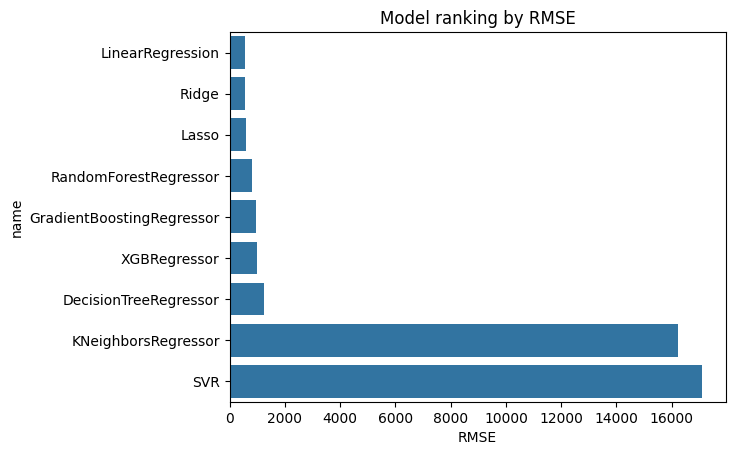

In [74]:
baseline_perfs = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
})

plt.title('Model ranking by RMSE')

sns.barplot(baseline_perfs.sort_values(by='RMSE'),
            x='RMSE',
            y='name');

According to the RMSE ranking, LinearRegression and Ridge are the best models.

In [78]:
save_perfs(baseline_perfs, 'baseline')

# HYPERPARAMETERS TUNING

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

## Preprocessing

In [96]:
cols = list(X_train.columns)

In [139]:
scaler = StandardScaler().fit(X_train)

X_train[cols], X_test[cols] = scaler.transform(X_train), scaler.transform(X_test)

C:\Users\KRYPTONIUM\AppData\Local\Temp\ipykernel_21820\2844421937.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[cols], X_test[cols] = scaler.transform(X_train), scaler.transform(X_test)


## Baseline models with preprocessing

In [123]:
reset()

### Linear models

In [124]:
eval_save_model(LinearRegression())
eval_save_model(Lasso())
eval_save_model(Ridge())

LinearRegression:
	RMSE:575.8762010337492
	R2-score:0.9891401951262968
Lasso:
	RMSE:578.4136512469945
	R2-score:0.9890455095700923
Ridge:
	RMSE:635.0891053580182
	R2-score:0.9865612494391123


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.642e+08, tolerance: 3.643e+07
  model = cd_fast.enet_coordinate_descent(


### Support Vector Machine

In [125]:
eval_save_model(SVR())

SVR:
	RMSE:16882.991328210013
	R2-score:-91690.09210435244


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### KNN

In [126]:
eval_save_model(KNeighborsRegressor())

KNeighborsRegressor:
	RMSE:2105.163363438437
	R2-score:0.8829840610684595


### Decision Tree

In [127]:
eval_save_model(DecisionTreeRegressor())

DecisionTreeRegressor:
	RMSE:1121.2882384608522
	R2-score:0.9595333000836097


### Ensemble Learning

In [128]:
eval_save_model(RandomForestRegressor())
eval_save_model(XGBRegressor())
eval_save_model(GradientBoostingRegressor())

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor:
	RMSE:790.8747220915453
	R2-score:0.9790896318043273
XGBRegressor:
	RMSE:976.56494140625
	R2-score:0.9665952920913696


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor:
	RMSE:941.8606581463573
	R2-score:0.9686682617951564


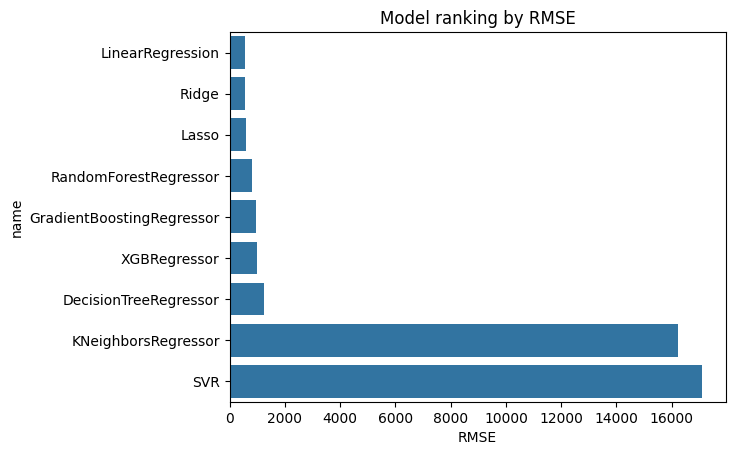

In [129]:
plt.title('Model ranking by RMSE')

sns.barplot(baseline_perfs.sort_values(by='RMSE'),
            x='RMSE',
            y='name');

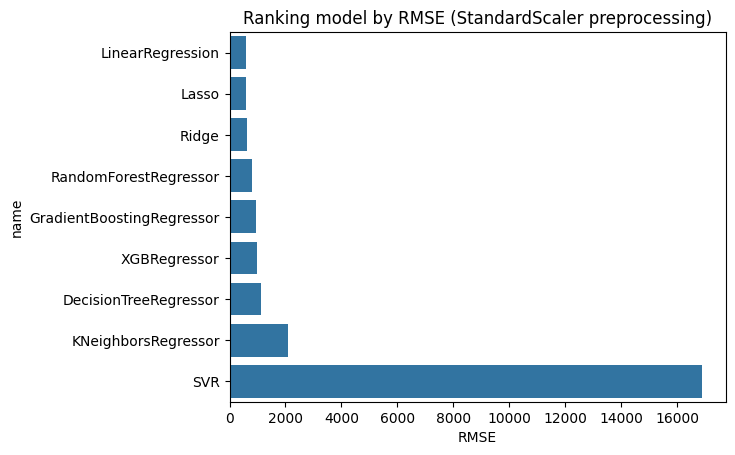

In [130]:
scaler_perfs = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
})

plt.title('Ranking model by RMSE (StandardScaler preprocessing)')
sns.barplot(scaler_perfs.sort_values(by='RMSE'),
           x='RMSE',
           y='name');

In [131]:
scaler_perfs

,name,RMSE,R2_score
0,LinearRegression,575.876201,0.989140
1,Lasso,578.413651,0.989046
2,Ridge,635.089105,0.986561
3,SVR,16882.991328,-91690.092104
4,KNeighborsRegressor,2105.163363,0.882984
5,DecisionTreeRegressor,1121.288238,0.959533
6,RandomForestRegressor,790.874722,0.979090
7,XGBRegressor,976.564941,0.966595
8,GradientBoostingRegressor,941.860658,0.968668


In [132]:
baseline_perfs

,name,RMSE,R2_score
0,LinearRegression,575.876201,0.989140
1,LinearRegression,575.876201,0.989140
2,Lasso,582.396239,0.988915
3,Ridge,575.876201,0.989140
4,SVR,17092.672981,-130362.529254
5,KNeighborsRegressor,16226.720525,-0.655287
6,DecisionTreeRegressor,1253.285264,0.951630
7,RandomForestRegressor,799.333770,0.978504
8,GradientBoostingRegressor,941.830068,0.968671
9,XGBRegressor,976.564941,0.966595


With StandardScaler preprocessing, model performance get worse

## Preprocessing with PolynomialFeatures